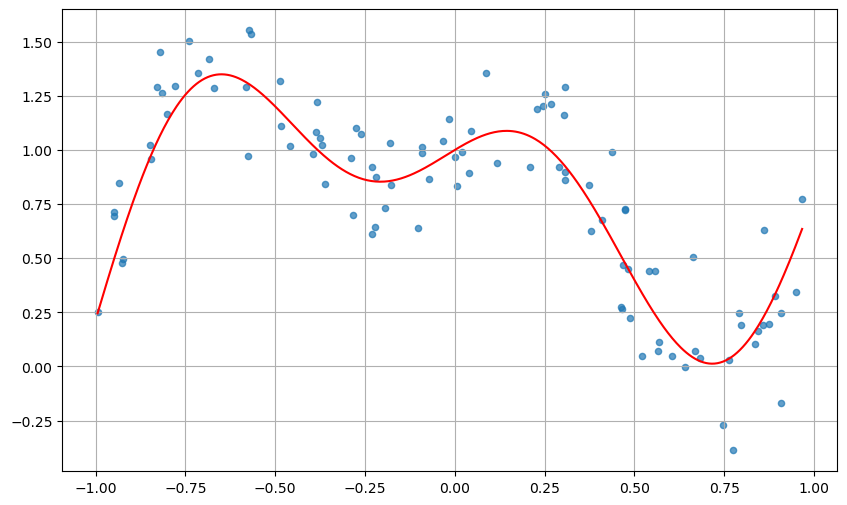

In [1]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt

# Set seeds for reproducibility
random.seed(499)
np.random.seed(499)

# Generate 100 points for x between -1 and 1
x = np.random.uniform(-1, 1, 100)

# Create y data based on the formula with noise
# (1+x^2)^(-1) + x*cos(5*x) + some small amount of noise
y = (1 + x**2)**(-1) + x * np.cos(5 * x) + np.random.normal(0, 0.2, size=x.shape)

# Create a DataFrame from x and y
df = pd.DataFrame({'x': x, 'y': y})

# Plotting the data
plt.figure(figsize=(10, 6))
plt.scatter(df['x'], df['y'], label='Data Points', s=20, alpha=0.7)

# Fit the underlying function to the data
# Generate points for the 'correct' line
x_fit = np.linspace(df['x'].min(), df['x'].max(), 500)
y_fit = (1 + x_fit**2)**(-1) + x_fit * np.cos(5 * x_fit)

# add the line to the plot
plt.plot(x_fit, y_fit, color='red')
plt.grid(True)
plt.show()


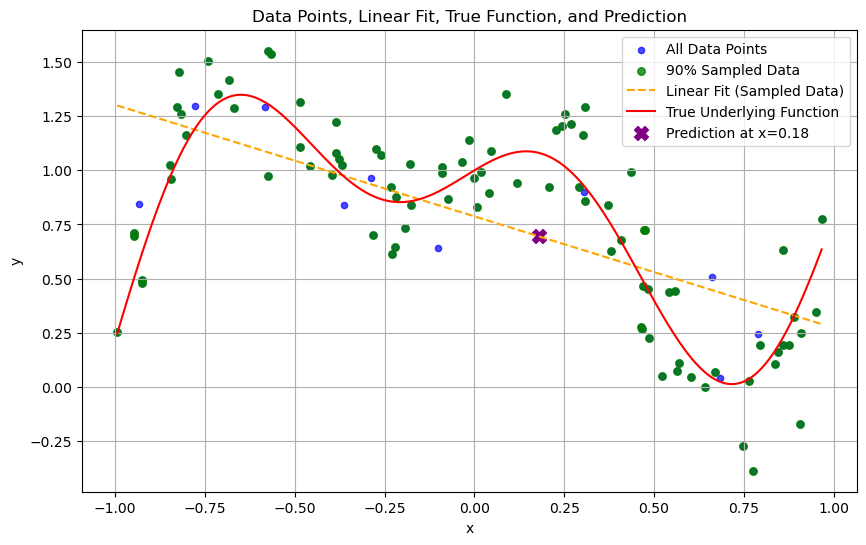

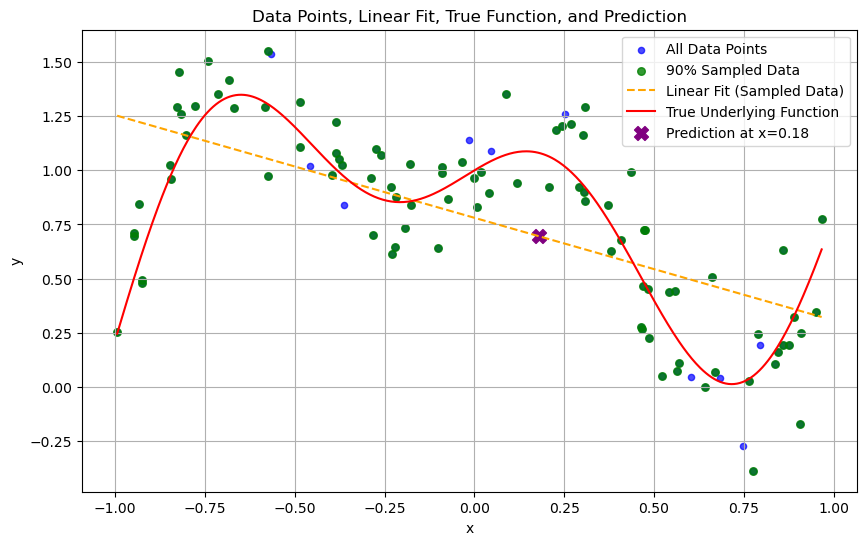

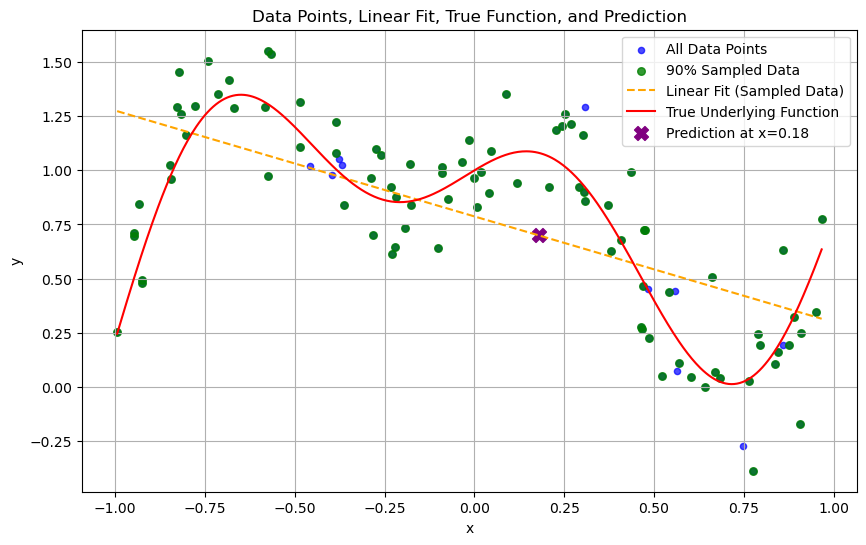

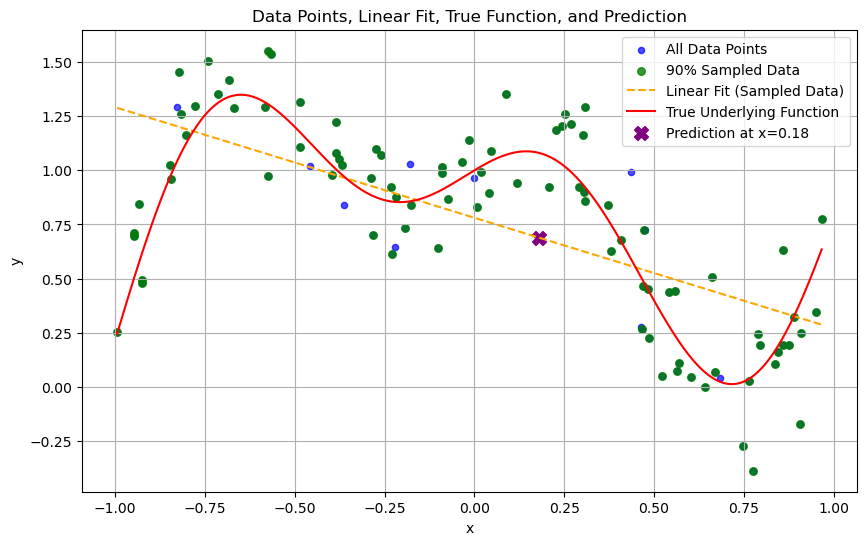

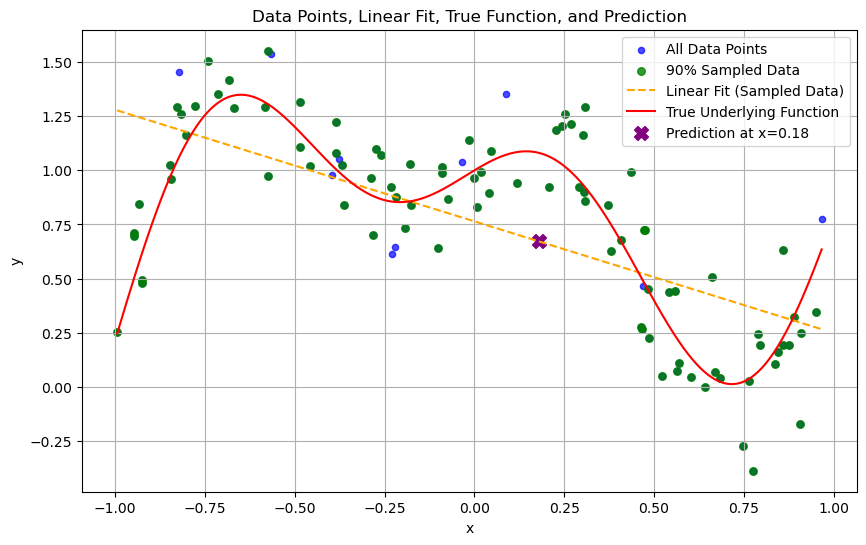

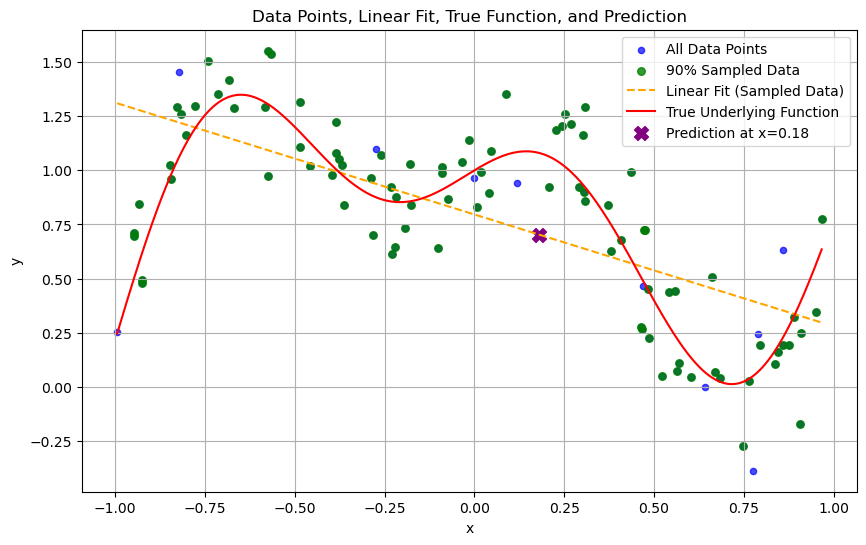

In [2]:
from sklearn.linear_model import LinearRegression

x_test_value = 0.18
predictions = []

for i in range(30):
    # Sample 90% of the points from df at random
    df_sample = df.sample(frac=0.9, random_state=499+i)

    # Fit a linear model to this data
    # Reshape x for sklearn's LinearRegression
    X_sample = df_sample['x'].values.reshape(-1, 1)
    y_sample = df_sample['y'].values

    model = LinearRegression()
    model.fit(X_sample, y_sample)

    # Predict a value for x = 0.18
    x_predict = np.array([[x_test_value]])
    y_predict = model.predict(x_predict)[0]

    # Save the prediction to a list
    predictions.append(y_predict)

    if i <= 5:
        # Plotting the data
        plt.figure(figsize=(10, 6))
        plt.scatter(df['x'], df['y'], label='All Data Points', s=20, alpha=0.7, color='blue')
        plt.scatter(df_sample['x'], df_sample['y'], label='90% Sampled Data', s=30, alpha=0.8, color='green')

        # Plot the resulting linear fit
        x_linear_fit = np.linspace(df['x'].min(), df['x'].max(), 100).reshape(-1, 1)
        y_linear_fit = model.predict(x_linear_fit)
        plt.plot(x_linear_fit, y_linear_fit, color='orange', linestyle='--', label='Linear Fit (Sampled Data)')

        # Fit the underlying function to the data (from previous code)
        x_true_fit = np.linspace(df['x'].min(), df['x'].max(), 500)
        y_true_fit = (1 + x_true_fit**2)**(-1) + x_true_fit * np.cos(5 * x_true_fit)
        plt.plot(x_true_fit, y_true_fit, color='red', label='True Underlying Function')

        # Add this to the plot in a different color
        plt.scatter(x_predict[0], y_predict, color='purple', marker='X', s=100, label=f'Prediction at x={x_predict[0,0]:.2f}')

        plt.title('Data Points, Linear Fit, True Function, and Prediction')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.legend()
        plt.grid(True)
        plt.show()

In [3]:
print("Correct y value: ", (1 + x_test_value**2)**(-1) + x_test_value * np.cos(5 * x_test_value))
print("Average prediction: ", np.mean(predictions))
print("Mean Error: ", ((1 + x_test_value**2)**(-1) + x_test_value * np.cos(5 * x_test_value)) - np.mean(predictions)) # large error
print("Variance of Predictions: ", np.var(predictions)) # low variability between different linear fits
# The linear model is generally high bias - low variance!

Correct y value:  1.0805066094766314
Average prediction:  0.6876019616289345
Mean Error:  0.39290464784769685
Variance of Predictions:  0.00011476095890542764


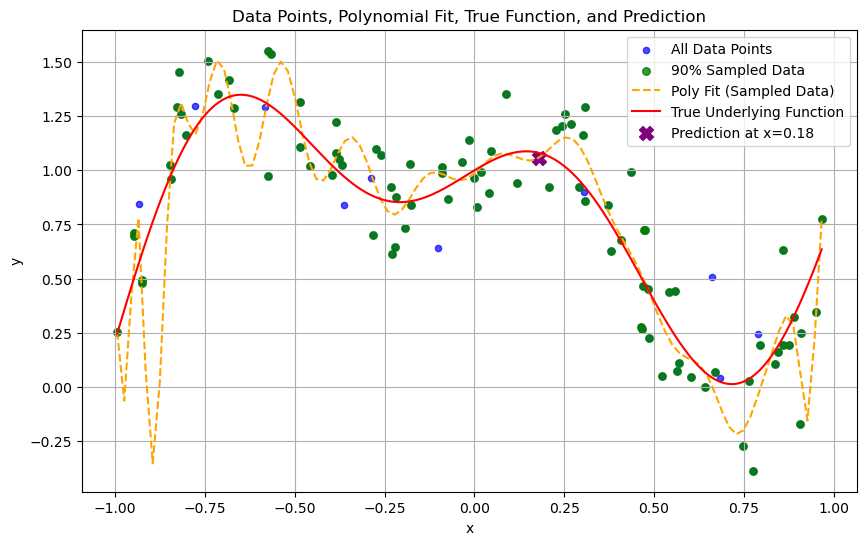

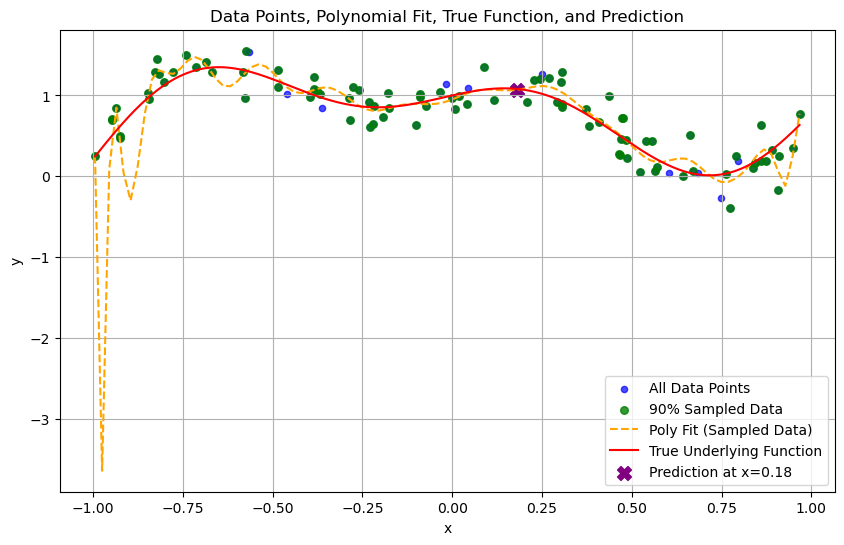

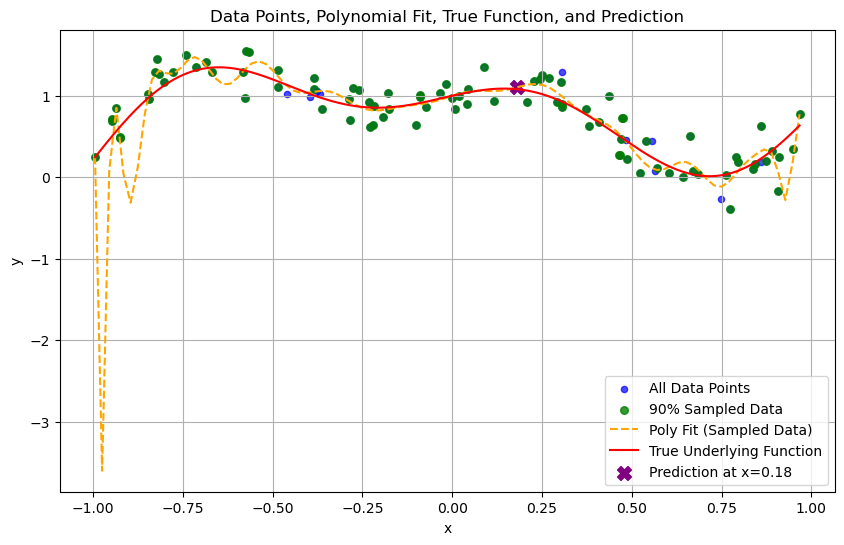

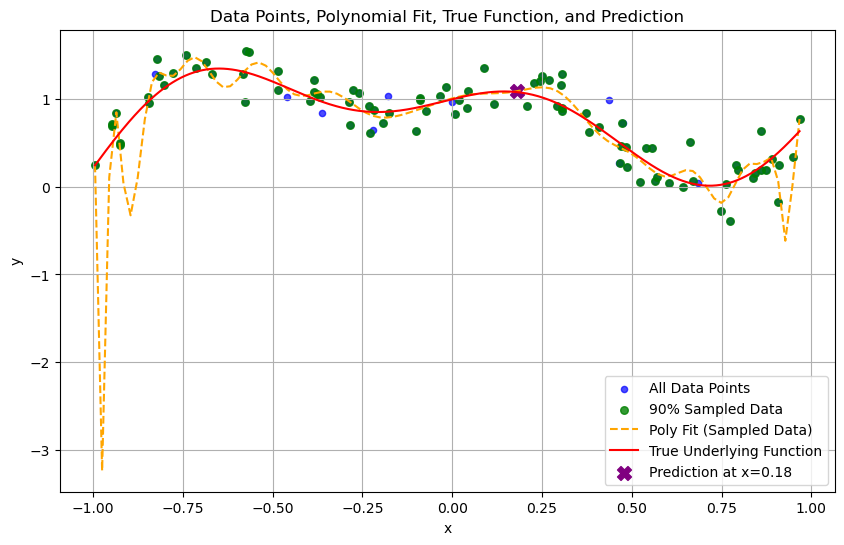

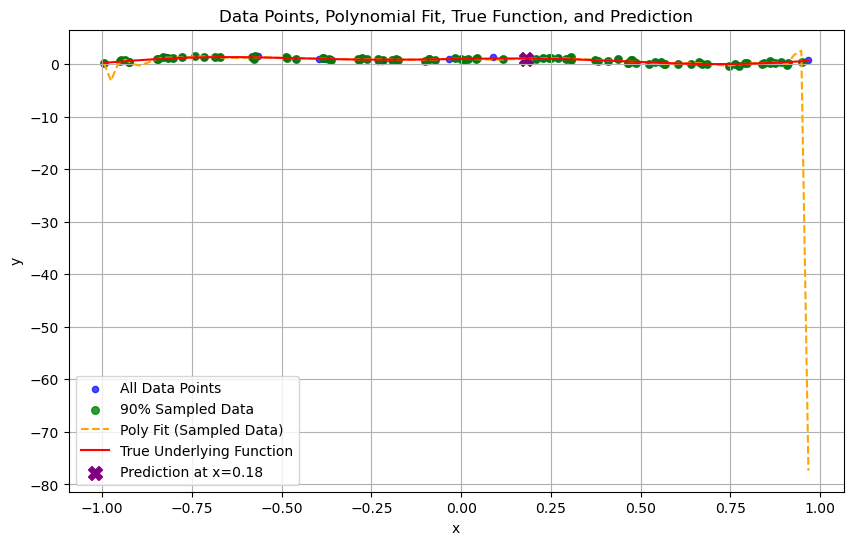

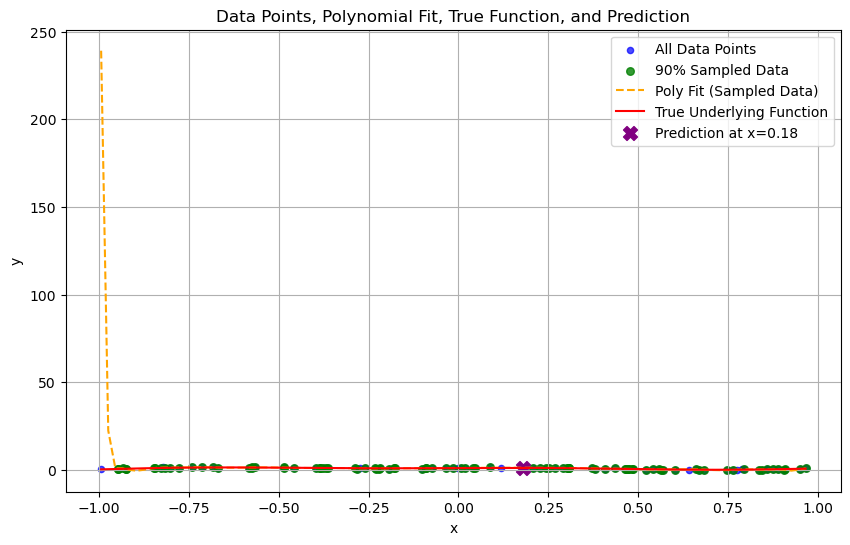

In [4]:
predictions_polynomial = []
degree = 30

for i in range(30):
    # Sample 90% of the points from df at random
    df_sample = df.sample(frac=0.9, random_state=499+i)

    # Fit a polynomial model to this data
    X_sample = df_sample['x'].values
    y_sample = df_sample['y'].values

    coefficients = np.polyfit(X_sample, y_sample, degree)
    poly_model = np.poly1d(coefficients)

    # Predict a value for x = 0.18
    x_predict = np.array([[x_test_value]])
    y_predict = poly_model(x_predict)

    # Save the prediction to a list
    predictions_polynomial.append(y_predict)

    if i <= 5:
        # Plotting the data
        plt.figure(figsize=(10, 6))
        plt.scatter(df['x'], df['y'], label='All Data Points', s=20, alpha=0.7, color='blue')
        plt.scatter(df_sample['x'], df_sample['y'], label='90% Sampled Data', s=30, alpha=0.8, color='green')

        # Plot the resulting polynomial fit
        x_poly_fit = np.linspace(df['x'].min(), df['x'].max(), 100).reshape(-1, 1)
        y_poly_fit = poly_model(x_poly_fit)
        plt.plot(x_poly_fit, y_poly_fit, color='orange', linestyle='--', label='Poly Fit (Sampled Data)')

        # Fit the underlying function to the data (from previous code)
        x_true_fit = np.linspace(df['x'].min(), df['x'].max(), 500)
        y_true_fit = (1 + x_true_fit**2)**(-1) + x_true_fit * np.cos(5 * x_true_fit)
        plt.plot(x_true_fit, y_true_fit, color='red', label='True Underlying Function')

        # Add this to the plot in a different color
        plt.scatter(x_predict[0], y_predict, color='purple', marker='X', s=100, label=f'Prediction at x={x_predict[0,0]:.2f}')

        plt.title('Data Points, Polynomial Fit, True Function, and Prediction')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.legend()
        plt.grid(True)
        plt.show()

In [5]:
print("Correct y value: ", (1 + x_test_value**2)**(-1) + x_test_value * np.cos(5 * x_test_value))
print("Average prediction: ", np.mean(predictions_polynomial))
print("Mean Error: ", ((1 + x_test_value**2)**(-1) + x_test_value * np.cos(5 * x_test_value)) - np.mean(predictions_polynomial)) # small error
print("Variance of Predictions: ", np.var(predictions_polynomial)) # high variability between different polynomial fits
# The polynomial model is generally low bias - high variance!

Correct y value:  1.0805066094766314
Average prediction:  1.0799493491811354
Mean Error:  0.0005572602954959649
Variance of Predictions:  0.002429364346402584
